# Imports

- This notebook repeats the analysis on the spatially de-trended outcome. 
- No spatial CV, instead regular 5 fold is performed
- Notebook is cleaned. All non-necesary code is removed
- PS is estimated by selecting the best calibrated classifier.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
import pickle
from tqdm import tqdm

import geopandas as gpd

In [2]:
from CAgsalML.causal import  dml_sensitivity_analysis
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

INFO (2025-12-04 13:11:54,873) [__init__/<module> (line 54)]: Using balance version 0.12.0


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, r2_score, brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.calibration import CalibrationDisplay, calibration_curve
from skopt.space import Categorical, Integer, Real

In [4]:
RANDOM_SEED = 43

In [ ]:
data = pd.read_pickle('../data-definitive/data-dag.pkl')
data = data.rename(columns={'0to100perc_season_prec': 'wthseason_rain'})

adjustment_nodes = [
    'neighborsAdvice', 'fieldHistory', 'weather',
    'investmentCap', 'soil', 'variety', 'otherManagement',
    'phenology', 'elevation', 'fertilizerAmount',
    'accessibilityRAI', 'crop'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed'
    ],
    'fertilizerAmount': ['fertN_total', 'fertP_total'],
    'accessibilityRAI': ['accessibility_rai'],
    'elevation': ['elevation_value'],
    'previousAdvice': ['treat_previousadvice'],
    'investmentCap': ['investing_capacity_index'],
    'weather': [
        '0to10perc_season_tmean', '0to10perc_season_srad',
        '0to10perc_season_prec', '0to10perc_season_rainydays',
        '10to20perc_season_tmean', '10to20perc_season_srad',
        '10to20perc_season_prec', '10to20perc_season_rainydays',
        '20to30perc_season_tmean', '20to30perc_season_srad',
        '20to30perc_season_prec', '20to30perc_season_rainydays',
        '30to40perc_season_tmean', '30to40perc_season_srad',
        '30to40perc_season_prec', '30to40perc_season_rainydays',
        '40to50perc_season_tmean', '40to50perc_season_srad',
        '40to50perc_season_prec', '40to50perc_season_rainydays',
        '50to60perc_season_tmean', '50to60perc_season_srad',
        '50to60perc_season_prec', '50to60perc_season_rainydays',
        '60to70perc_season_tmean', '60to70perc_season_srad',
        '60to70perc_season_prec', '60to70perc_season_rainydays',
        '70to80perc_season_tmean', '70to80perc_season_srad',
        '70to80perc_season_prec', '70to80perc_season_rainydays',
        '80to90perc_season_tmean', '80to90perc_season_srad',
        '80to90perc_season_prec', '80to90perc_season_rainydays',
        '90to100perc_season_tmean', '90to100perc_season_srad',
        '90to100perc_season_prec', '90to100perc_season_rainydays',
        '0to100perc_season_tmean', '0to100perc_season_srad',
        'wthseason_rain', '0to100perc_season_rainydays',
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 'fertN_emergence',
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_emergence', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'neighborsAdvice': ['neighbor_previousadvice_avg'],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'phenology': ['phenology_losstd'],
    'crop': ['crop_maize'],
}
outcome_name = 'outcome_prodstd'
treatment_name = 'treat_previousadvice'
# Bad controls
bad_controls = [i for c in (set(columns_dict) - set(adjustment_nodes)) for i in columns_dict[c]]
features = [i for v in columns_dict.values() for i in v]
features = list(set(features) - set(bad_controls) - {outcome_name, treatment_name})

In [6]:
set(data.columns) - set(features)

{'crop_name',
 'fertN_56leaves',
 'fertN_810leaves',
 'fertN_basal',
 'fertN_emergence',
 'fertN_kneehigh',
 'fertN_tasselingsilking',
 'fertP_56leaves',
 'fertP_810leaves',
 'fertP_basal',
 'fertP_emergence',
 'fertP_kneehigh',
 'fertP_tasselingsilking',
 'outcome_prodkgha',
 'outcome_prodstd',
 'phenology_losdays',
 'score_inputs',
 'score_land',
 'score_mech',
 'treat_previousadvice'}

In [7]:
# Import geometries to assign spatial groups for CV
crs = 'EPSG:32736'

points = gpd.read_file('../data-definitive/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)

admin = gpd.read_file('../data-definitive/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], how="left", predicate="within")
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'})
# Drop the 'index_right' column which is a byproduct of the sjoin
points = points.drop(columns=['index_right'])

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle('../data-definitive/maize-soya-clean.pkl')

# Get subset
index_zone_subset = points.geometry.x.where(lambda x: x > 6e5).dropna().index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

# Add lan, lon as features
data['lat'] = (points.geometry.y - points.geometry.y.mean())/points.geometry.y.std()
data['lon'] = ((points.geometry.x - points.geometry.x.mean())/points.geometry.x.std())
features.extend(['lat', 'lon'])

In [8]:
# cols_to_drop = [
#     'crop_name', 'outcome_prodkgha', 
# ]
# features = list((set(data.columns) - {treatment_name, outcome_name}) - set(cols_to_drop))
T_series = data[treatment_name].astype(int)
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
dummy_features = list((data.loc[:, data.isin([0, 1]).all()].columns))
numeric_features = list(set(numeric_features) - set(dummy_features))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)

# Transform the outcome crop-wise
tmp_series = data.loc[data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.loc[~data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = transformed_data.outcome_prodstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)
# Drop those rows with no production
transformed_data = transformed_data.loc[transformed_data.outcome_prodstd.notna()]
# Drop rows with values not within feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
transformed_data = transformed_data[features+[outcome_name]]
clean_data = clean_data.loc[index_zone_subset]

In [9]:
# Spatially demean the outcome
spatial_transformer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer.fit(transformed_data.outcome_prodstd)
transformed_data['outcome_prodstd'] = spatial_transformer.transform_demean()

In [10]:
# Add treatment and Keep only complete records
transformed_data[treatment_name] = data[treatment_name]
transformed_data = transformed_data.dropna()
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [11]:
transformed_data.describe().transpose().head(50)

,count,mean,std,min,25%,50%,75%,max
neighbor_previousadvice_avg,1337.0,-0.049928,0.979277,-0.809578,-0.805549,-0.699300,1.063616,2.482912
50to60perc_season_srad,1337.0,-0.014412,0.933379,-2.366284,-0.543102,-0.113309,0.329007,4.588272
elevation_value,1337.0,0.029828,0.993843,-3.175887,-0.429582,0.300205,0.799533,1.923021
70to80perc_season_tmean,1337.0,-0.026396,0.948658,-2.578116,-0.553803,-0.074399,0.441520,3.908483
investing_capacity_index,1337.0,-0.027240,0.955530,-1.295754,-0.721582,-0.182926,0.349811,3.635021
0to10perc_season_prec,1337.0,0.014802,0.994352,-1.889041,-0.925128,0.101517,0.727177,3.114210
40to50perc_season_prec,1337.0,-0.015169,0.968360,-2.280671,-0.653450,-0.058665,0.558702,3.867802
accessibility_rai,1337.0,-0.001812,0.986069,-3.885089,-0.265791,-0.096871,0.080218,3.206901
70to80perc_season_srad,1337.0,0.004098,1.004185,-1.981683,-0.758121,-0.207391,0.684352,3.441514
0to10perc_season_tmean,1337.0,-0.018027,0.989404,-2.041825,-0.860174,-0.124665,0.652647,2.846425


# PS and Outcome function

## PS model

In [12]:
# Optimize a PS model to get a calibrated PS
optimizer_ps = GPOptimizer(
    model=LogisticRegression,
    model_kwargs=dict(
        C=Real(name='C', low=1.e-2, high=2),
        # class_weight=Categorical(name='class_weight', categories=[None, 'balanced']), 
        penalty='l2', 
        # solver='liblinear',
        max_iter=1000, 
        random_state=RANDOM_SEED
    )
)

def cal_r2_score(y_true, y_score):
    r2 = r2_score(*calibration_curve(y_true, y_score))
    if np.isnan(r2):
        return -99.
    return r2
X_train = transformed_data[features]
t_train = transformed_data[treatment_name]
model_ps, cv_scores_ps = optimizer_ps.cv_optimize(
    X_train, t_train,
    cv=5, 
    cv_kwargs=dict(
        n_jobs=-1, 
        # scoring=make_scorer(cal_r2_score, greater_is_better=True, response_method='predict_proba')
        scoring='neg_brier_score'
    ),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED),
)

In [13]:
model_ps = model_ps.fit(X_train, t_train)
print(f'CV BSS mean: {np.mean(1 - -cv_scores_ps.mean()/np.mean((t_train-t_train.mean())**2)):.3f}')
y_proba = model_ps.predict_proba(X_train)[:, 1]
train_score = brier_score_loss(y_true=t_train, y_proba=y_proba)
train_score = 1 - train_score/brier_score_loss(y_true=t_train, y_proba=np.ones_like(t_train)*t_train.mean())
print(f'Train BSS: {train_score:.3f}')

CV BSS mean: 0.334
Train BSS: 0.510


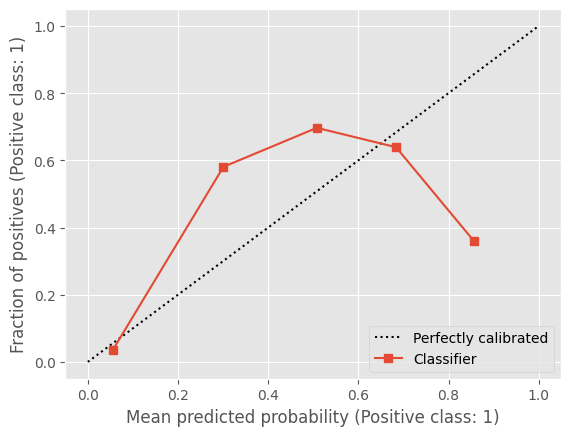

In [14]:
# ConfusionMatrixDisplay.from_estimator(model_f, X_test, t_test)
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 1)
propensity_score = cross_val_predict(model_ps, X_train, t_train, method='predict_proba')[:, 1] # Honest Propensity Score
propensity_score = pd.Series(propensity_score, index=transformed_data.index)
disp = CalibrationDisplay.from_predictions(
    y_true=t_train, y_prob=propensity_score,
    ax=ax, 
)

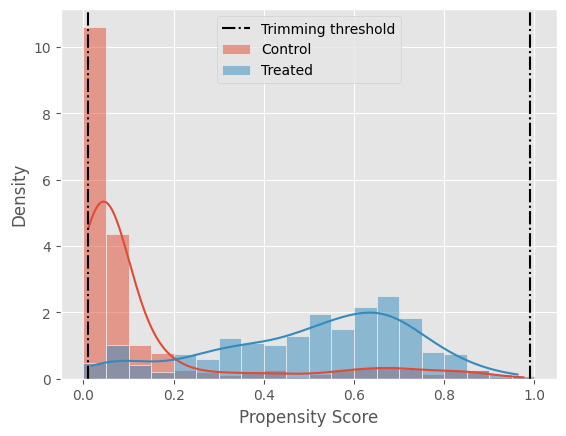

In [15]:
fig, ax = plt.subplots(1, 1)
bins = np.linspace(0, 1, 21)
ax = sns.histplot(
    x=propensity_score[~t_train],
    element='bars', stat='density', kde=True,
    label='Control', bins=bins, 
)
ax = sns.histplot(
    x=propensity_score[t_train],
    element='bars', stat='density', kde=True,
    label='Treated', bins=bins,
)
ax.legend()
ax.set_xlabel('Propensity Score')
ax.axvline(0.01, linestyle='-.', color='k', label='Trimming threshold')
ax.axvline(0.99, linestyle='-.', color='k')
ax.legend()

In [16]:
propensity_score[~t_train].max()

np.float64(0.9754200108648341)

In [17]:
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed['propensity_score'] = propensity_score
# This trimmed is the same done by Chernozhukov in the DML paper
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[(propensity_score > 0.01) & (propensity_score < 0.99)].copy()

index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(1337, 83)

In [18]:
pd.Series(model_ps.coef_[0], index=features).abs().sort_values(ascending=False).head(10)

neighbor_previousadvice_avg    1.554180
history_oilseed                0.299675
70to80perc_season_srad         0.223156
10to20perc_season_prec         0.203297
20to30perc_season_srad         0.200895
90to100perc_season_tmean       0.192436
80to90perc_season_rainydays    0.175820
fertN_total                    0.174179
70to80perc_season_prec         0.171718
soil_sandy                     0.171443
dtype: float64

## Outcome model $q(X, W)$

In [19]:
# Define spatial groups as Admin2
spatial_group = 'ADM2_PCODE'
groups = points[spatial_group].unique()
len(groups)

3

In [20]:
x_names = [
    'investing_capacity_index', 
    'wthseason_rain', 'soilpp_sand', 
    # 'crop_maize'
]
w_names = list(set(features) - set(x_names))


training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED)
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

1002 training samples
335 testing samples
N features: 80


In [21]:
X_train = transformed_data_pstrimmed.loc[training_idxs, w_names + x_names]
y_train = transformed_data_pstrimmed.loc[training_idxs, outcome_name]
groups_train = points.loc[training_idxs, spatial_group]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [22]:
model_q = model_q.fit(X_train, y_train)
test_score = r2_score(
    y_true=transformed_data_pstrimmed.loc[testing_idxs, outcome_name],
    y_pred=model_q.predict(transformed_data_pstrimmed.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_q):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(y_train, model_q.predict(X_train)):.3f}')

CV R2 mean: 0.116
Test R2: 0.124
Train R2: 0.704


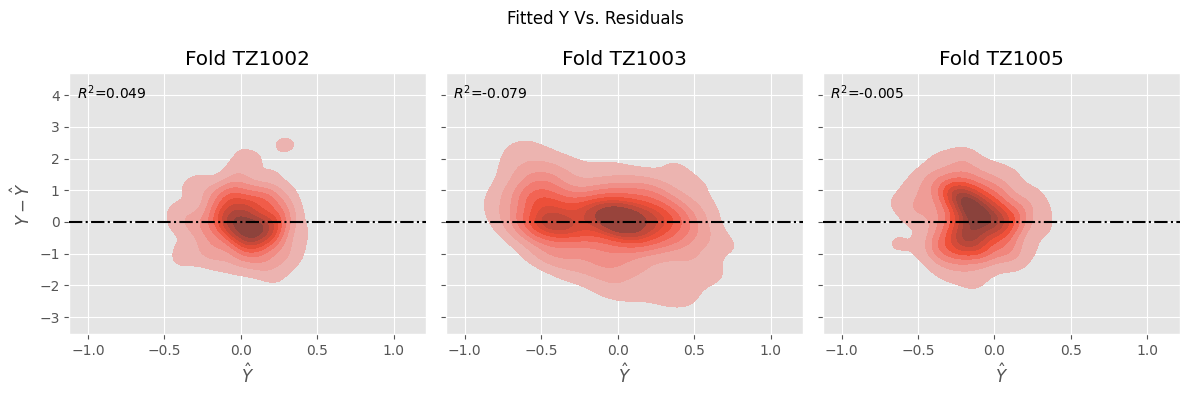

In [23]:
from sklearn.base import clone

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
axes = axes.flatten()
for n, gr in enumerate(groups):
    ax = axes[n]
    tmp_model = clone(model_q)
    tmp_idx = points.index[points[spatial_group] != gr]
    tmp_X = transformed_data_pstrimmed.loc[tmp_idx, w_names + x_names]
    tmp_y = transformed_data_pstrimmed.loc[tmp_idx, outcome_name]

    tmp_model = tmp_model.fit(tmp_X, tmp_y)

    tmp_idx = points.index[points[spatial_group] == gr]
    tmp_X = transformed_data_pstrimmed.loc[tmp_idx, w_names + x_names]
    tmp_y = transformed_data_pstrimmed.loc[tmp_idx, outcome_name]
    y_pred = tmp_model.predict(tmp_X)

    sns.kdeplot(
        x=y_pred, 
        y= tmp_y - y_pred,
        ax=ax,
        zorder=2, fill=True
    )
    
    ax.set_title(f'Fold {gr}')
    ax.axhline(0, color='k', zorder=3, linestyle='-.')
    ax.set_xlabel(r"$\hat{Y}$")
    ax.set_ylabel(r"$Y - \hat{Y}$")
    ax.text(
        0.02, 0.90, r'$R^2$='+f'{r2_score(tmp_y, y_pred):.3f}',
        transform=ax.transAxes
    )
fig.suptitle('Fitted Y Vs. Residuals')
plt.tight_layout()

## Linear regression

In [24]:
# A df for the ATT and ATE of the different methods
effects_df = pd.DataFrame(
    columns=pd.MultiIndex.from_product([('ate', 'att'), ('value', 'se', 'p-value', 'ci-low', 'ci-high')])
)

In [25]:
# Estimate ATT
from sklearn.linear_model import LinearRegression
n_samples = len(transformed_data_pstrimmed)
N_BOOTSTRAP = 500

bootstrap_lr = []
for _ in tqdm(range(N_BOOTSTRAP)):
    chunk_indexes = np.random.choice(transformed_data_pstrimmed.index, size=n_samples, replace=True)
    X_tmp = transformed_data_pstrimmed.loc[chunk_indexes, w_names + x_names + [treatment_name]]
    y_tmp = transformed_data_pstrimmed.loc[chunk_indexes, outcome_name]
    lr_model = LinearRegression()
    lr_model = lr_model.fit(X_tmp, y_tmp)
    bootstrap_lr.append(lr_model.__dict__)
lr_coefs = pd.DataFrame([i['coef_'] for i in bootstrap_lr], columns=features+[treatment_name])
lr_coefs['intercept'] = [i['intercept_'] for i in bootstrap_lr]

effects_df.loc['LR', ('ate', 'value')] = lr_coefs[treatment_name].mean()
effects_df.loc['LR', ('ate', 'se')] = lr_coefs[treatment_name].std()
effects_df.loc['LR', ('ate', 'p-value')] = (lr_coefs[treatment_name] > 0).mean()
effects_df.loc['LR', [('ate', 'ci-low'), ('ate', 'ci-high')]] = lr_coefs[treatment_name].quantile((0.025, 0.975)).values

effects_df

100%|██████████| 500/500 [00:05<00:00, 94.66it/s] 


ate                                         att                      \
       value        se p-value    ci-low   ci-high value   se p-value ci-low   
LR  0.064936  0.076427   0.814 -0.086158  0.220873   NaN  NaN     NaN    NaN   

            
   ci-high  
LR     NaN

## Propensity Score Matching

In [26]:
from sklearn.neighbors import KNeighborsRegressor

bootstrap_psm_ate = []
bootstrap_psm_att = []
for _ in tqdm(range(N_BOOTSTRAP)):
    chunk_indexes = np.random.choice(transformed_data_pstrimmed.index, size=n_samples, replace=True)
    X_tmp = propensity_score.loc[chunk_indexes].values.reshape((-1, 1))
    y_tmp = transformed_data_pstrimmed.loc[chunk_indexes, outcome_name]
    t_tmp = transformed_data_pstrimmed.loc[chunk_indexes, treatment_name]
    psm_model_treat = KNeighborsRegressor(1)
    psm_model_treat = psm_model_treat.fit(X_tmp[t_tmp], y_tmp[t_tmp])
    psm_model_control = KNeighborsRegressor(1)
    psm_model_control = psm_model_control.fit(X_tmp[~t_tmp], y_tmp[~t_tmp])
    bootstrap_psm_ate.append(
        (psm_model_treat.predict(X_tmp) - psm_model_control.predict(X_tmp)).mean()
    )
    bootstrap_psm_att.append(
        (y_tmp[t_tmp] - psm_model_control.predict(X_tmp[t_tmp])).mean()
    )
bootstrap_psm_ate = np.array(bootstrap_psm_ate)
bootstrap_psm_att = np.array(bootstrap_psm_att)


effects_df.loc['PSM', ('ate', 'value')] = bootstrap_psm_ate.mean()
effects_df.loc['PSM', ('ate', 'se')] = bootstrap_psm_ate.std()
effects_df.loc['PSM', ('ate', 'p-value')] = (bootstrap_psm_ate > 0).mean()
effects_df.loc['PSM', [('ate', 'ci-low'), ('ate', 'ci-high')]] = np.quantile(bootstrap_psm_ate, (0.025, 0.975))

effects_df.loc['PSM', ('att', 'value')] = bootstrap_psm_att.mean()
effects_df.loc['PSM', ('att', 'se')] = bootstrap_psm_att.std()
effects_df.loc['PSM', ('att', 'p-value')] = (bootstrap_psm_att > 0).mean()
effects_df.loc['PSM', [('att', 'ci-low'), ('att', 'ci-high')]] = np.quantile(bootstrap_psm_att, (0.025, 0.975))

effects_df

100%|██████████| 500/500 [00:01<00:00, 267.93it/s]


ate                                             att            \
        value        se p-value    ci-low   ci-high     value        se   
LR   0.064936  0.076427   0.814 -0.086158  0.220873       NaN       NaN   
PSM  0.044691  0.194502   0.568 -0.286218  0.420207  0.005133  0.095569   

                                 
    p-value    ci-low   ci-high  
LR      NaN       NaN       NaN  
PSM   0.518 -0.190315  0.198265

## DML 

In [27]:
from econml.dml import LinearDML, SparseLinearDML, CausalForestDML
from econml.inference import BootstrapInference

bootstrap = BootstrapInference(N_BOOTSTRAP, bootstrap_type='percentile')
# bootstrap = 'statsmodels'

In [28]:
W = transformed_data_pstrimmed.loc[:, features]
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

lineardml_hom_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_ps, 
    discrete_treatment=True,
    cv=5,
    random_state=RANDOM_SEED
)
lineardml_hom_estimate = lineardml_hom_estimate.fit(
    Y=Y, T=T, W=W,
    inference=bootstrap, cache_values=True
)
effects_df.loc['LinearDML-Hom', ('ate', 'value')] = lineardml_hom_estimate.ate()
effects_df.loc['LinearDML-Hom', ('ate', 'se')] = lineardml_hom_estimate.ate_inference().stderr_mean
effects_df.loc['LinearDML-Hom', ('ate', 'p-value')] = lineardml_hom_estimate.ate_inference().pvalue()
effects_df.loc['LinearDML-Hom', [('ate', 'ci-low'), ('ate', 'ci-high')]] = lineardml_hom_estimate.ate_interval()

effects_df

ate                                               att  \
                  value        se   p-value    ci-low   ci-high     value   
LR             0.064936  0.076427     0.814 -0.086158  0.220873       NaN   
PSM            0.044691  0.194502     0.568 -0.286218  0.420207  0.005133   
LinearDML-Hom  0.034462  0.049097  0.482726 -0.061765   0.13069       NaN   

                                                     
                     se p-value    ci-low   ci-high  
LR                  NaN     NaN       NaN       NaN  
PSM            0.095569   0.518 -0.190315  0.198265  
LinearDML-Hom       NaN     NaN       NaN       NaN

### KFold 5 multiple X

In [29]:
W = transformed_data_pstrimmed.loc[:, list(set(features) - set(x_names))].to_numpy()
X = transformed_data_pstrimmed.loc[:, x_names].to_numpy()
interaction1_idx = x_names.index('investing_capacity_index')
interaction2_idx = x_names.index('soilpp_sand')
X = np.hstack([
    X,
    (X[:, interaction1_idx] * X[:, interaction2_idx]).reshape(-1, 1)
])
x_names_cate = x_names + ['sand:invest']
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

dml_estimator = LinearDML(
    model_y=model_q, 
    model_t=model_ps, 
    discrete_treatment=True,
    cv=5, 
    random_state=RANDOM_SEED
)
dml_estimator = dml_estimator.fit(
    Y=Y, T=T, X=X, W=W, 
    inference=bootstrap, 
    cache_values=True
)

effects_df.loc['LinearDML-Het', ('att', 'value')] = dml_estimator.ate_inference(X[T==1]).mean_point
effects_df.loc['LinearDML-Het', ('att', 'se')] = dml_estimator.ate_inference(X[T==1]).stderr_mean
effects_df.loc['LinearDML-Het', ('att', 'p-value')] = dml_estimator.ate_inference(X[T==1]).pvalue()
effects_df.loc['LinearDML-Het', [('att', 'ci-low'), ('att', 'ci-high')]] = dml_estimator.ate_interval(X[T==1])

effects_df.loc['LinearDML-Het', ('ate', 'value')] = dml_estimator.ate_inference(X).mean_point
effects_df.loc['LinearDML-Het', ('ate', 'se')] = dml_estimator.ate_inference(X).stderr_mean
effects_df.loc['LinearDML-Het', ('ate', 'p-value')] = dml_estimator.ate_inference(X).pvalue()
effects_df.loc['LinearDML-Het', [('ate', 'ci-low'), ('ate', 'ci-high')]] = dml_estimator.ate_interval(X)

effects_df

ate                                               att  \
                  value        se   p-value    ci-low   ci-high     value   
LR             0.064936  0.076427     0.814 -0.086158  0.220873       NaN   
PSM            0.044691  0.194502     0.568 -0.286218  0.420207  0.005133   
LinearDML-Hom  0.034462  0.049097  0.482726 -0.061765   0.13069       NaN   
LinearDML-Het  0.049017  0.097982  0.616887 -0.143025  0.241059  0.048058   

                                                       
                     se   p-value    ci-low   ci-high  
LR                  NaN       NaN       NaN       NaN  
PSM            0.095569     0.518 -0.190315  0.198265  
LinearDML-Hom       NaN       NaN       NaN       NaN  
LinearDML-Het  0.097307  0.621392 -0.142661  0.238776

In [30]:
dml_estimator.summary(feature_names=x_names_cate)

,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
investing_capacity_index,-0.017,0.045,-0.378,0.382,-0.1,0.077
wthseason_rain,-0.005,0.055,-0.082,0.44,-0.09,0.119
soilpp_sand,0.03,0.04,0.737,0.19,-0.047,0.11
sand:invest,0.047,0.046,1.014,0.156,-0.037,0.147
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
cate_intercept,0.047,0.048,0.985,0.204,-0.051,0.135


In [31]:
# Get the coefficients for all bootsrap instances
coefs_instances = []
for est in dml_estimator._inference._est._instances:
    coefs_instances.append(
        pd.read_html(est.summary(feature_names=x_names_cate).tables[0].as_html(), header=0, index_col=0)[0].transpose()
    )
    coefs_instances[-1]['cate_intercept'] = pd.read_html(est.summary(feature_names=x_names_cate).tables[1].as_html(), header=0, index_col=0)[0].transpose()
coefs_instances = pd.concat(coefs_instances)

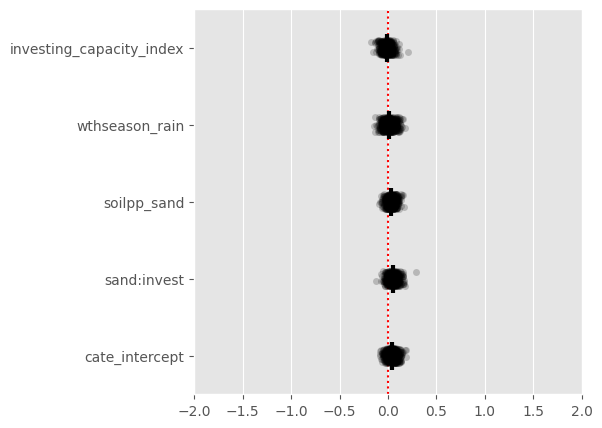

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.stripplot(
    data=coefs_instances.loc['point_estimate'], orient='h',
    alpha=.2, legend=False, color='k'
)

sns.pointplot(
    coefs_instances.loc['point_estimate'],
    color='k', orient='h', linewidth=1.2, zorder=2,
    linestyle='none', errorbar=None, marker="|",
    markersize=20, markeredgewidth=3
)
ax.axvline(0, color='r', linestyle=":", zorder=1)
ax.set_xlim(-2, 2)


In [33]:
def add_cate(conditional_mask, description):
    effects_df.loc[description, ('ate', 'value')] = dml_estimator.ate_inference(X[conditional_mask]).mean_point
    effects_df.loc[description, ('ate', 'se')] = dml_estimator.ate_inference(X[conditional_mask]).stderr_mean
    effects_df.loc[description, ('ate', 'p-value')] = dml_estimator.ate_inference(X[conditional_mask]).pvalue()
    effects_df.loc[description, [('ate', 'ci-low'), ('ate', 'ci-high')]] = dml_estimator.ate_interval(X[conditional_mask])

In [34]:
effects_df

ate                                               att  \
                  value        se   p-value    ci-low   ci-high     value   
LR             0.064936  0.076427     0.814 -0.086158  0.220873       NaN   
PSM            0.044691  0.194502     0.568 -0.286218  0.420207  0.005133   
LinearDML-Hom  0.034462  0.049097  0.482726 -0.061765   0.13069       NaN   
LinearDML-Het  0.049017  0.097982  0.616887 -0.143025  0.241059  0.048058   

                                                       
                     se   p-value    ci-low   ci-high  
LR                  NaN       NaN       NaN       NaN  
PSM            0.095569     0.518 -0.190315  0.198265  
LinearDML-Hom       NaN       NaN       NaN       NaN  
LinearDML-Het  0.097307  0.621392 -0.142661  0.238776

In [35]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
soya_std = clean_data.loc[index_zone_subset].soyaprodkg_ha.std()
maize_std, soya_std

In [36]:
np.array(dml_estimator.nuisance_scores_).mean(axis=2), np.array(dml_estimator.nuisance_scores_).std(axis=2)

(array([[0.15612036],
        [0.85714406]]),
 array([[0.03457856],
        [0.0130409 ]]))

In [37]:
dml_estimator.score_

## Sensitivity analysis

In [38]:
dml_estimator.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
===============================================
CI Lower Theta Lower Theta Theta Upper CI Upper
-----------------------------------------------
   -0.22      -0.081 0.048       0.178    0.318
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.019                   0.0
----------------------------------------------
"""

## Placebo test

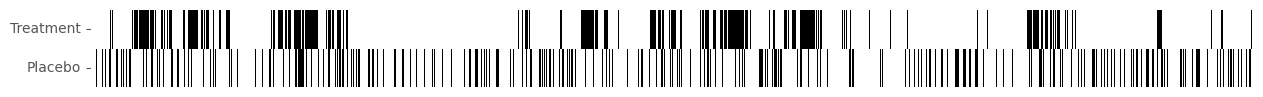

In [39]:
T_placebo = np.where(
    np.random.uniform(size=len(T)) < T.mean(),
    True, False
)

fig, ax = plt.subplots(1, 1, figsize=(15, 1))
sns.heatmap(
    np.vstack((T , T_placebo)), ax=ax, cmap='Greys',
    cbar=False
)
ax.set_ylabel('')
ax.set_yticklabels(['Treatment', 'Placebo'], rotation=0)
ax.set_xticks([])


In [40]:
from tqdm import tqdm
placebo_summaries = []
placebo_estimates = []

for _ in tqdm(range(N_BOOTSTRAP)):
    T_placebo = np.random.choice(T, size=len(T), replace=False)

    dml_placebo_estimator = LinearDML(
        model_y=model_q, 
        model_t=model_ps, 
        discrete_treatment=True,
        cv=5, 
        random_state=RANDOM_SEED
    )
    dml_placebo_estimator = dml_placebo_estimator.fit(
        Y=Y, T=T_placebo, X=X, W=W, 
        inference='statsmodels', cache_values=True
    )
    placebo_estimates.append((
        dml_placebo_estimator.ate_inference(X),
        dml_placebo_estimator.ate_inference(X[T==1])
    ))
    placebo_summaries.append(dml_placebo_estimator.summary(feature_names=x_names_cate))

100%|██████████| 500/500 [14:55<00:00,  1.79s/it]


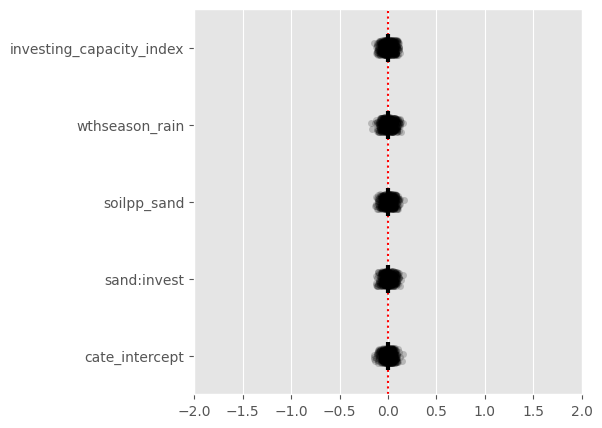

In [41]:
# Get the coefficients for all bootsrap instances
coefs_instances_placebo = []
for est in placebo_summaries:
    coefs_instances_placebo.append(
        pd.read_html(est.tables[0].as_html(), header=0, index_col=0)[0].transpose()
    )
    coefs_instances_placebo[-1]['cate_intercept'] = pd.read_html(est.tables[1].as_html(), header=0, index_col=0)[0].transpose()
coefs_instances_placebo = pd.concat(coefs_instances_placebo)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.stripplot(
    data=coefs_instances_placebo.loc['point_estimate'], orient='h',
    alpha=.2, legend=False, color='k'
)

sns.pointplot(
    coefs_instances_placebo.loc['point_estimate'],
    color='k', orient='h', linewidth=1.2, zorder=2,
    linestyle='none', errorbar=None, marker="|",
    markersize=20, markeredgewidth=3
)
ax.axvline(0, color='r', linestyle=":", zorder=1)
ax.set_xlim(-2, 2)


In [42]:
reg_prefix = 'east'
effects_df.to_pickle(f'../data-definitive/results/effects-{reg_prefix}.pkl')
transformed_data_pstrimmed.to_pickle(f'../data-definitive/results/transformed-subset-pstrimmed-{reg_prefix}.pkl')
coefs_instances.to_pickle(f'../data-definitive/results/coefs-dmllinear-instances-{reg_prefix}.pkl')
coefs_instances_placebo.to_pickle(f'../data-definitive/results/coefs-dmllinear-instances-placebo-{reg_prefix}.pkl')